# **Credit Card Fraud Detection** #

     

### ***Business Understanding*** ###

``` markdown
Dalam Institusi Bank, data analitik dapat membantu perusahaan bank dalam mendeteksi fraud. Fraud dapat menyebabkan banyak kerugian terhadap bank tersebut. Tujuan utama dari fraud detection adalah mendeteksi kerugian dari dataset yang sudah disediakan. Projek ini dapat mengurangi terjadinya fraud dalam keuangan sekaligus melindungi aset perusahaan serta kepercayaan masyarakat terhadap bank tersebut.

Projek ini dapat diukur melalui f1-score, recall model deteksi, dan efisiensi operational dalam deteksi fraud

Tantangan utama dalam mendeteksi fraud ini adalah ketidak seimbangannya data, resiko false positive (dapat menyebabkan kesalahan dalam deteksi pelanggan). Oleh karena itu metode Machine Learning akan membantu perusahaan bank dalam mendeteksi terjadinya fraud.

In [1]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint, uniform


In [3]:
df = pd.read_csv('fraud_detection_data.csv', sep = ',', encoding = 'latin-1', )

In [4]:
df.sample(5)

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Date,Payment_Method,Product_Category,Quantity,Customer_Age,Customer_Location,Device_Used,IP_Address,Shipping_Address,Billing_Address,Fraudulent,Account_Age_Days,Transaction_Hour
24381,93accf79-f573-4484-8db6-57c414114eda,638f5190-205a-438d-bd83-a2dac34fe294,503.70,2/21/2024 21:40,credit card,home & garden,1,23,Farrellton,mobile,222.213.63.56,"48204 Sydney Neck Suite 664\nEast Seth, PR 96810","48204 Sydney Neck Suite 664\nEast Seth, PR 96810",1,19,5
49363,8ba8a6dd-ced9-4428-865e-4eb540315435,e39a61a4-fe6d-42a0-a0be-3c77e28ff474,114.78,3/26/2024 6:10,bank transfer,home & garden,4,29,Haydenport,mobile,213.232.246.155,"6882 Moreno Springs\nMitchellport, KS 64323","6882 Moreno Springs\nMitchellport, KS 64323",0,208,6
33476,ba278cbf-dac0-41c3-a451-51b12aa53c4f,bd574c65-e80b-4e02-ba7a-625d5a387d8e,55.75,2/3/2024 2:51,debit card,home & garden,2,26,Hodgesmouth,tablet,194.150.121.63,"833 Melissa Fort\nWallacemouth, FM 37958","833 Melissa Fort\nWallacemouth, FM 37958",0,31,2
21983,536e4438-63f6-44e0-b443-dc1df14d3d1f,94927a29-fbc3-4016-9403-29022035fb7f,65.76,1/12/2024 8:51,PayPal,health & beauty,5,22,North Ericville,mobile,171.205.104.57,"7414 Johnson Wells\nCookfurt, DC 74177","916 Yu Fort Apt. 625\nEast Rachelbury, NC 73398",0,132,8
36109,0c3c547b-be19-4990-95f6-5d972a26af71,a9ca5c5d-cada-451b-a125-6bb31d3d8a54,80.28,3/16/2024 9:44,PayPal,toys & games,5,51,Housechester,tablet,192.61.195.211,"412 Lawson Ways\nEast Jackburgh, MD 72645","412 Lawson Ways\nEast Jackburgh, MD 72645",0,103,9


### **Exploratory Data Analysis - EDA** ###

In [5]:
df.describe()

,Transaction_Amount,Quantity,Customer_Age,Fraudulent,Account_Age_Days,Transaction_Hour
count,56478.000000,56478.000000,56478.000000,56478.000000,56478.000000,56478.000000
mean,226.322701,2.993095,34.520486,0.050055,179.478009,11.288342
std,263.576461,1.413245,10.002779,0.218060,106.668757,6.971933
min,10.000000,1.000000,-4.000000,0.000000,1.000000,0.000000
25%,68.165000,2.000000,28.000000,0.000000,86.000000,5.000000
50%,152.235000,3.000000,34.000000,0.000000,180.000000,11.000000
75%,297.027500,4.000000,41.000000,0.000000,271.000000,17.000000
max,5888.450000,5.000000,74.000000,1.000000,365.000000,23.000000


In [6]:
df.value_counts()

Transaction_ID                        Customer_ID                           Transaction_Amount  Transaction_Date  Payment_Method  Product_Category  Quantity  Customer_Age  Customer_Location  Device_Used  IP_Address       Shipping_Address                                         Billing_Address                                          Fraudulent  Account_Age_Days  Transaction_Hour
fffffeda-3415-421b-bbe2-4c4b9f7542e8  bac8a8e7-c7a3-465c-b2be-3115ac849aa8  174.77              2/17/2024 0:01    PayPal          electronics       3         25            Theresastad        mobile       182.74.2.98      475 Jones Springs Apt. 478\nNorth Margaret, NM 61618     475 Jones Springs Apt. 478\nNorth Margaret, NM 61618     0           108               0                   1
000242df-6a98-48ba-a42d-7d516074a4dc  c5412932-5e76-4008-b5cb-60b5bb326521  225.98              1/22/2024 8:18    bank transfer   home & garden     5         30            Harmonview         tablet       52.199.162.29    7286 Misty

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56478 entries, 0 to 56477
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      56478 non-null  object 
 1   Customer_ID         56478 non-null  object 
 2   Transaction_Amount  56478 non-null  float64
 3   Transaction_Date    56478 non-null  object 
 4   Payment_Method      56478 non-null  object 
 5   Product_Category    56478 non-null  object 
 6   Quantity            56478 non-null  int64  
 7   Customer_Age        56478 non-null  int64  
 8   Customer_Location   56478 non-null  object 
 9   Device_Used         56478 non-null  object 
 10  IP_Address          56478 non-null  object 
 11  Shipping_Address    56478 non-null  object 
 12  Billing_Address     56478 non-null  object 
 13  Fraudulent          56478 non-null  int64  
 14  Account_Age_Days    56478 non-null  int64  
 15  Transaction_Hour    56478 non-null  int64  
dtypes: f

In [8]:
df.isnull().sum()

Transaction_ID        0
Customer_ID           0
Transaction_Amount    0
Transaction_Date      0
Payment_Method        0
Product_Category      0
Quantity              0
Customer_Age          0
Customer_Location     0
Device_Used           0
IP_Address            0
Shipping_Address      0
Billing_Address       0
Fraudulent            0
Account_Age_Days      0
Transaction_Hour      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
import pandas as pd

# Create a DataFrame with all the data from df (56478 rows)
export_df = df.copy()

# Export to CSV file
csv_filename = 'fraud_detection_data.csv'
export_df.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' has been created with {len(export_df)} rows")
print(f"File saved successfully!")

CSV file 'fraud_detection_data.csv' has been created with 56478 rows
File saved successfully!


### **Data Preprocessing** ###

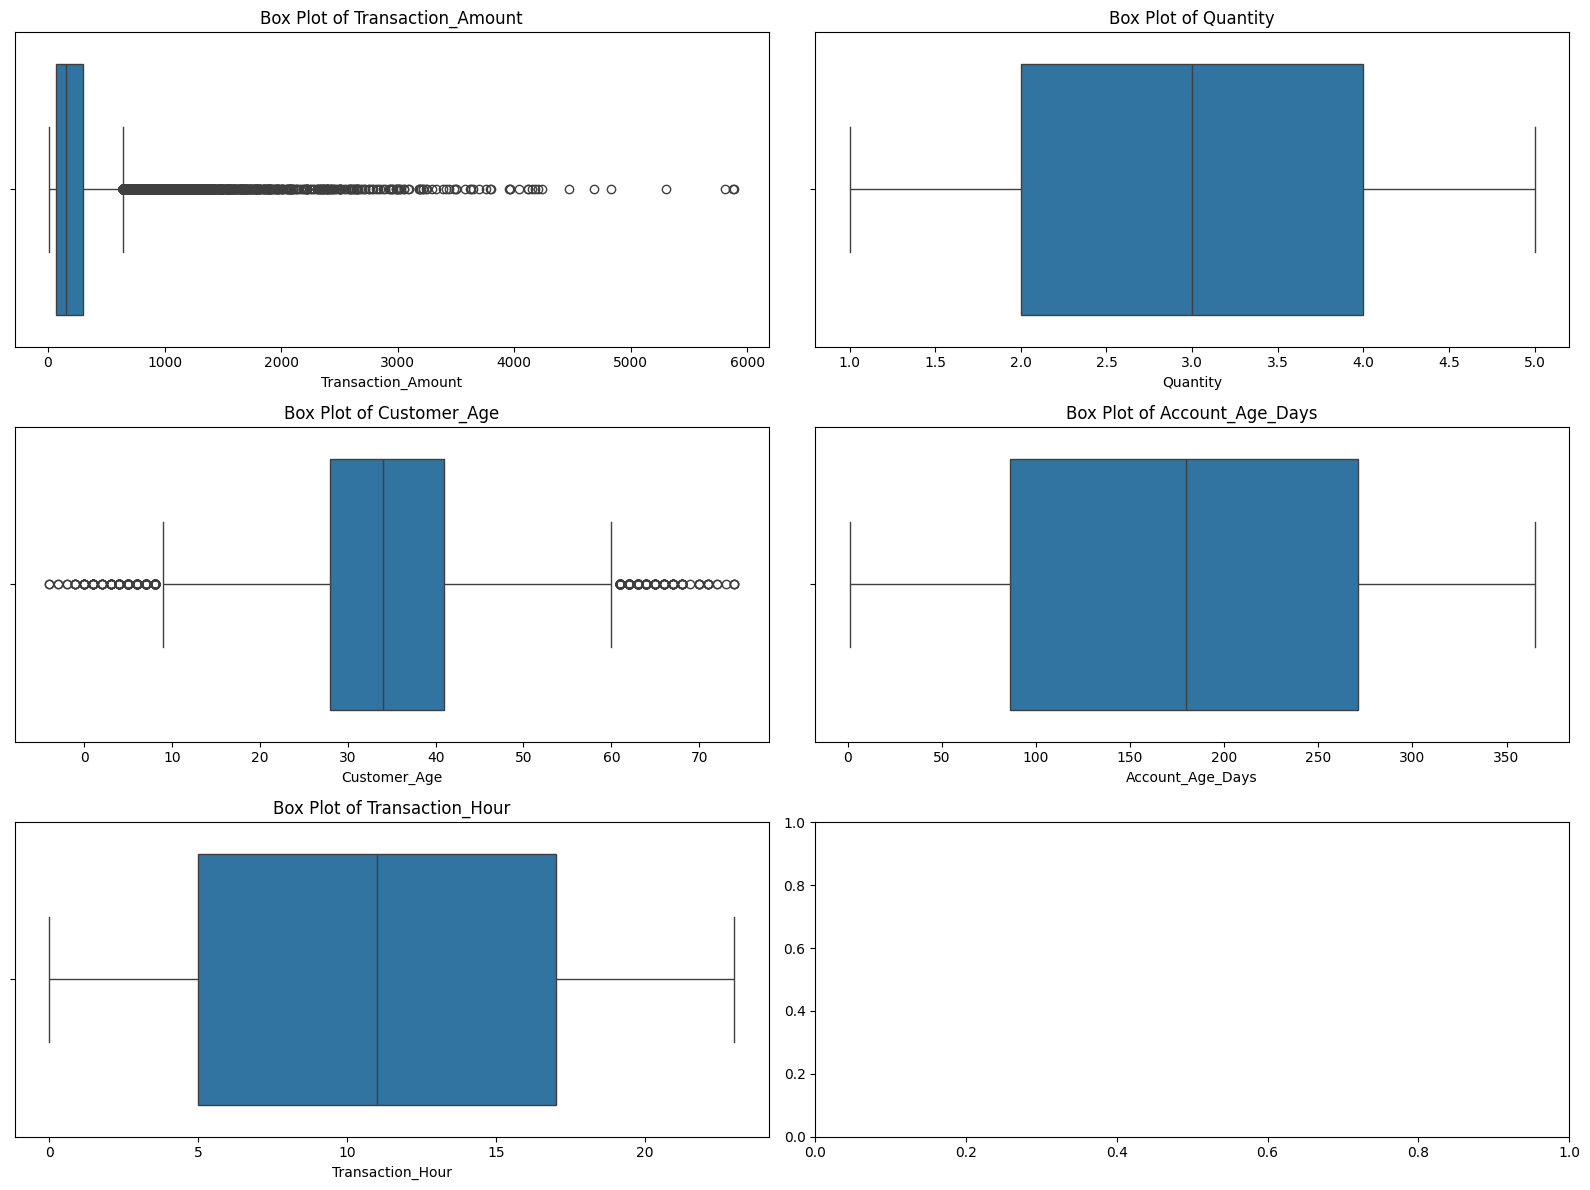

In [11]:
features = ['Transaction_Amount', 'Quantity', 'Customer_Age', 'Account_Age_Days', 'Transaction_Hour']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

In [12]:
# menangani outliers di kolom 'Customer_Age'
mean_age = df['Customer_Age'].mean()
df.loc[df['Customer_Age'] < 10, 'Customer_Age'] = mean_age

C:\Users\Joe\AppData\Local\Temp\ipykernel_16528\442369001.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '34.520485852898474' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Customer_Age'] < 10, 'Customer_Age'] = mean_age


In [13]:
df.describe()

,Transaction_Amount,Quantity,Customer_Age,Fraudulent,Account_Age_Days,Transaction_Hour
count,56478.000000,56478.000000,56478.000000,56478.000000,56478.000000,56478.000000
mean,226.322701,2.993095,34.696593,0.050055,179.478009,11.288342
std,263.576461,1.413245,9.745141,0.218060,106.668757,6.971933
min,10.000000,1.000000,10.000000,0.000000,1.000000,0.000000
25%,68.165000,2.000000,28.000000,0.000000,86.000000,5.000000
50%,152.235000,3.000000,34.520486,0.000000,180.000000,11.000000
75%,297.027500,4.000000,41.000000,0.000000,271.000000,17.000000
max,5888.450000,5.000000,74.000000,1.000000,365.000000,23.000000


In [14]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount',
       'Transaction_Date', 'Payment_Method', 'Product_Category', 'Quantity',
       'Customer_Age', 'Customer_Location', 'Device_Used', 'IP_Address',
       'Shipping_Address', 'Billing_Address', 'Fraudulent', 'Account_Age_Days',
       'Transaction_Hour'],
      dtype='object')

```markdown
Dalam dataset ini ada beberapa kolom yang akan di drop seperti Transaction_ID, Customer_ID, Transaction_Date, Customer_Location, Shipping_Address, Billing_Address, IP_Address agar data dapat diproses lebih lanjut. Namun sebelum drop kolom diatas ini, ada kolom baru yang akan saya buat untuk melihat apakah data Shipping_Address dan Billing_Address itu sama.

```

In [15]:
df['Address_Match'] = (df['Shipping_Address'] == df['Billing_Address']).astype(int)

In [16]:
df = df.drop(["Transaction_ID","Customer_ID","Customer_Location","Transaction_Date","IP_Address","Shipping_Address","Billing_Address"], axis=1)

In [17]:
df.sample(5)

,Transaction_Amount,Payment_Method,Product_Category,Quantity,Customer_Age,Device_Used,Fraudulent,Account_Age_Days,Transaction_Hour,Address_Match
26836,270.22,bank transfer,clothing,3,20.0,tablet,0,271,0,1
6781,702.14,PayPal,health & beauty,1,27.0,desktop,0,363,0,1
26084,516.24,PayPal,home & garden,5,32.0,mobile,0,103,11,0
10632,54.39,bank transfer,toys & games,1,38.0,mobile,0,295,18,1
17887,188.75,PayPal,electronics,4,26.0,mobile,0,50,23,1


### **Feature Understanding** ###

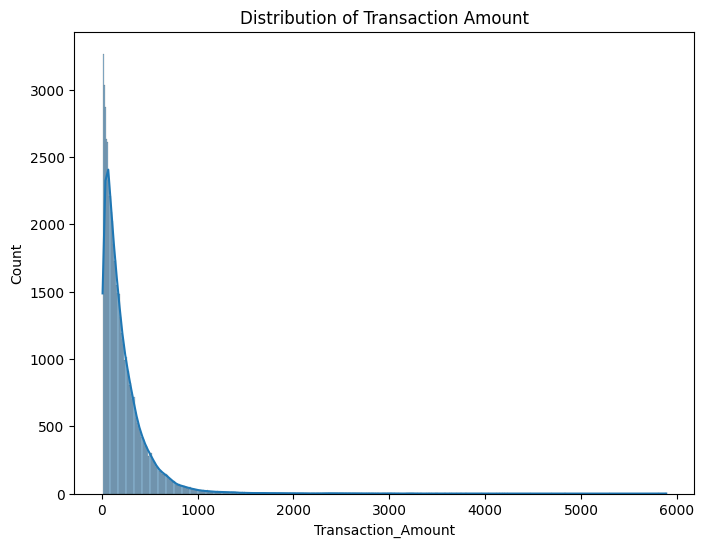

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Transaction_Amount'], kde=True)
plt.xlabel('Transaction_Amount')
plt.ylabel('Count')
plt.title('Distribution of Transaction Amount')
plt.show()

```markdown

Data diatas terlihat sangat miring/skewed

```

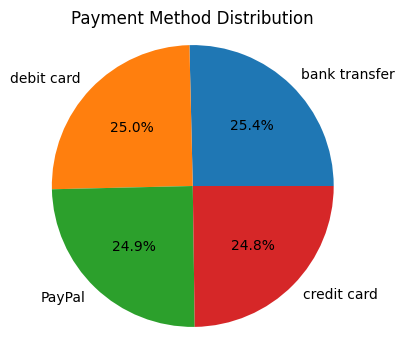

In [19]:
plt.figure(figsize=(4, 4))
plt.pie(df['Payment_Method'].value_counts(), labels=df['Payment_Method'].unique(), autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.axis('equal')
plt.show()

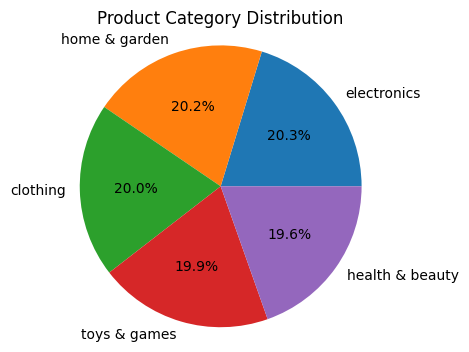

In [20]:
plt.figure(figsize=(4, 4))
plt.pie(df['Product_Category'].value_counts(), labels=df['Product_Category'].unique(), autopct='%1.1f%%')
plt.title('Product Category Distribution')
plt.axis('equal')
plt.show()

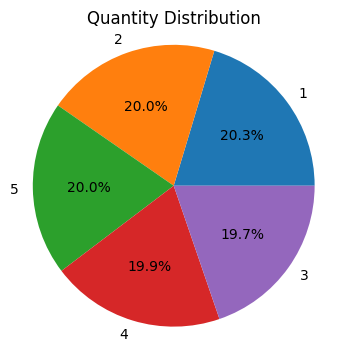

In [21]:
plt.figure(figsize=(4, 4))
plt.pie(df['Quantity'].value_counts(), labels=df['Quantity'].unique(), autopct='%1.1f%%')
plt.title('Quantity Distribution')
plt.axis('equal')
plt.show()

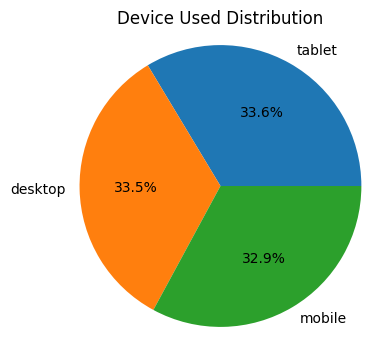

In [22]:
plt.figure(figsize=(4, 4))
plt.pie(df['Device_Used'].value_counts(), labels=df['Device_Used'].unique(), autopct='%1.1f%%')
plt.title('Device Used Distribution')
plt.axis('equal')
plt.show()

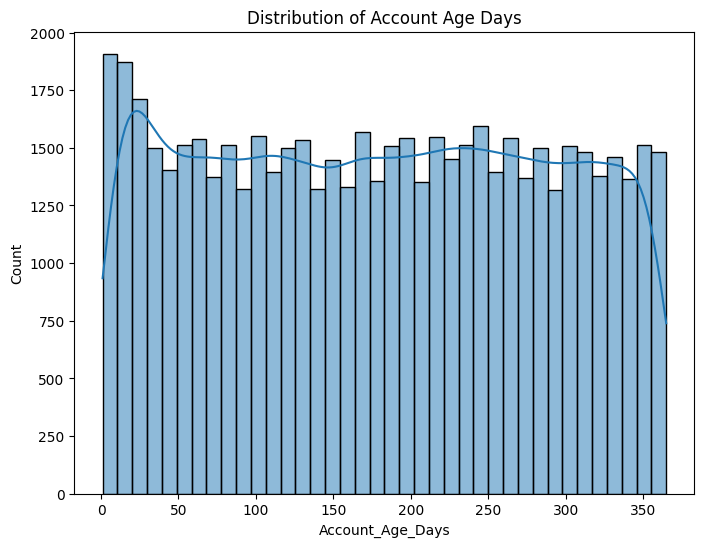

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Account_Age_Days'], kde=True)
plt.xlabel('Account_Age_Days')
plt.ylabel('Count')
plt.title('Distribution of Account Age Days')
plt.show()


Hasil Analisa dari Account_Age_Days (Umur dari akun)

- Distribusi usia akun pelanggan cenderung right-skewed (miring ke kanan)
- Mayoritas akun memiliki usia antara `0-200 hari`
- Frekuensi tertinggi berada pada rentang `0-50 hari`, Namun terdapat beberapa akun dengan usia lebih dari `400 hari` yang jumlahnya relatif sedikit
- Akun-akun baru (< 100 hari) mendominasi distribusi, menunjukkan banyak pelanggan baru yang membuat akun


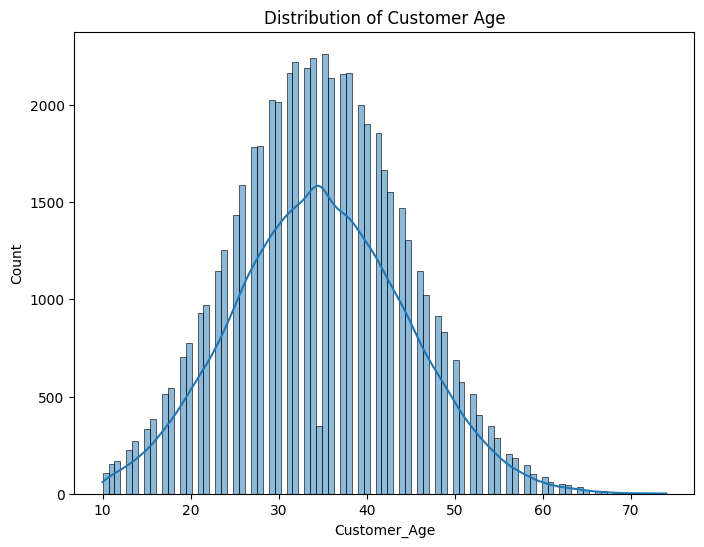

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Customer_Age'], kde=True)
plt.xlabel('Customer_Age')
plt.ylabel('Count')
plt.title('Distribution of Customer Age')
plt.show()

```markdown
Berdasarkan histogram Customer Age yang ditampilkan, dapat dilihat bahwa:

- Distribusi usia pelanggan cenderung normal/simetris dengan sedikit kemiringan ke kanan (right-skewed)
- Mayoritas pelanggan berada pada rentang usia 25-45 tahun
- Puncak distribusi berada di sekitar usia 30-35 tahun
- Terdapat beberapa outlier di usia yang sangat muda (<20 tahun) dan usia yang lebih tua (>60 tahun)
```

## **Feature Understanding - Visualization** ##

```markdown
Pada Feature Understanding proses ini akan mengidentifikasi profil atau karakteristik pelanggan yang lebih cenderung terlibat dalam transaksi penipuan. Dan memahami apa saja fitur atau karakteristik paling penting yang berkontribusi terhadap kemungkinan suatu transaksi bersifat penipuan
```

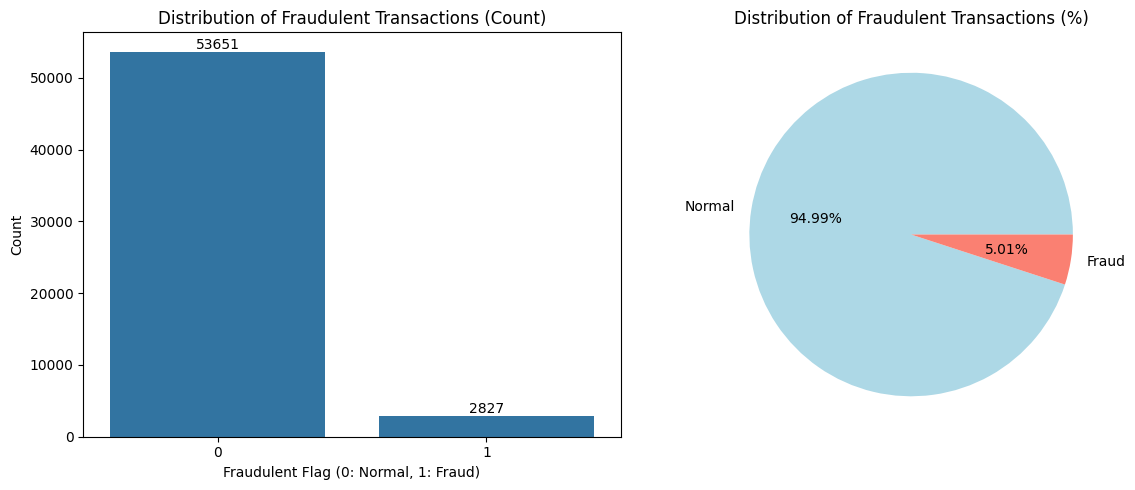

In [25]:
# bikin visualisasi distribusi kolom 'Fraudulent' dengan count plot dan pie chart
plt.figure(figsize=(12, 5))

# plot
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Fraudulent')
plt.title('Distribution of Fraudulent Transactions (Count)')
plt.xlabel('Fraudulent Flag (0: Normal, 1: Fraud)')
plt.ylabel('Count')

# Add count labels on top of bars
counts = df['Fraudulent'].value_counts()
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

# pie chart
plt.subplot(1, 2, 2)
plt.pie(counts, labels=['Normal', 'Fraud'], autopct='%1.2f%%', colors=['lightblue', 'salmon'])
plt.title('Distribution of Fraudulent Transactions (%)')
plt.tight_layout()
plt.show()


Berdasarkan visualisasi dan analisis data di atas, dapat disimpulkan

 **Distribusi Label (Fraudulent vs Non-Fraudulent)**

    - 95.0% transaksi adalah normal (53,651 transaksi)

    - 5.0% transaksi adalah fraud (2,827 transaksi)
    
    - Data sangat tidak seimbang (imbalanced)


In [26]:
fraud_groups = df.groupby('Fraudulent')

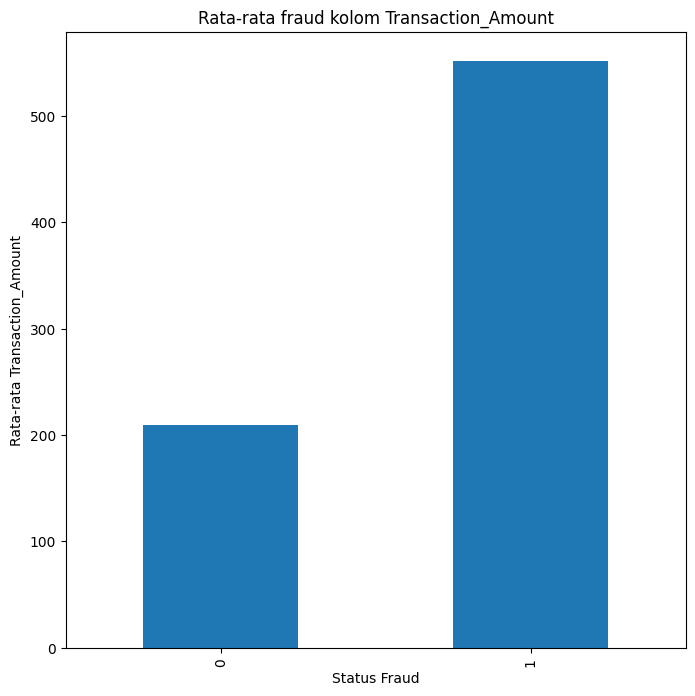

In [27]:
feature_mean = fraud_groups['Transaction_Amount'].mean()
plt.figure(figsize=(8, 8))
feature_mean.plot(kind='bar')
plt.xlabel('Status Fraud')
plt.ylabel('Rata-rata Transaction_Amount')
plt.title('Rata-rata fraud kolom Transaction_Amount')
plt.show()

Text(0.5, 1.0, 'Distribusi fraud dari metode pembayaran')

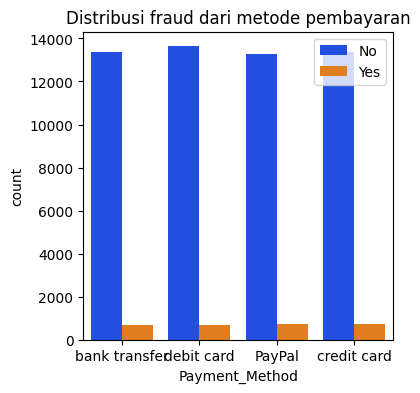

In [28]:
plt.figure(figsize=(4,4))
sns.countplot(x="Payment_Method", data=df, palette='bright', hue='Fraudulent')
plt.legend(['No','Yes'])
plt.title('Distribusi fraud dari metode pembayaran')

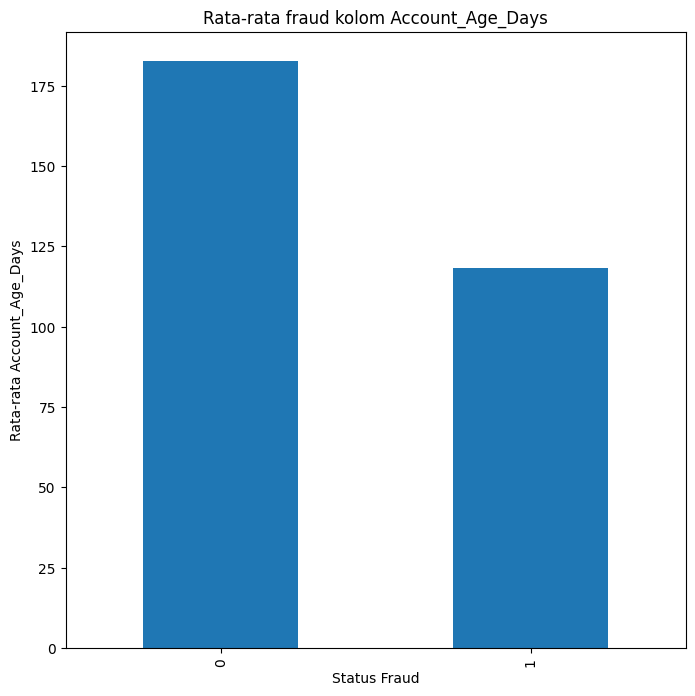

In [29]:
feature_mean = fraud_groups['Account_Age_Days'].mean()
plt.figure(figsize=(8, 8))
feature_mean.plot(kind='bar')
plt.xlabel('Status Fraud')
plt.ylabel('Rata-rata Account_Age_Days')
plt.title('Rata-rata fraud kolom Account_Age_Days')
plt.show()

Text(0.5, 1.0, 'Fraudulent Distribution Based on Quantity')

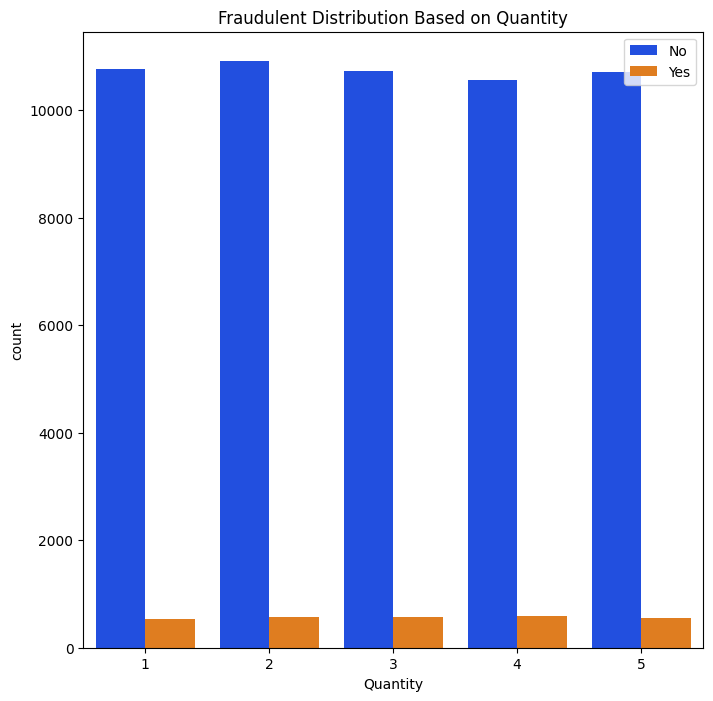

In [30]:
plt.figure(figsize=(8,8))
sns.countplot(x="Quantity", data=df, palette='bright',hue='Fraudulent')
plt.legend(['No','Yes'])
plt.title('Fraudulent Distribution Based on Quantity')

Text(0.5, 1.0, 'Fraudulent Distribution Based on Transaction Hour')

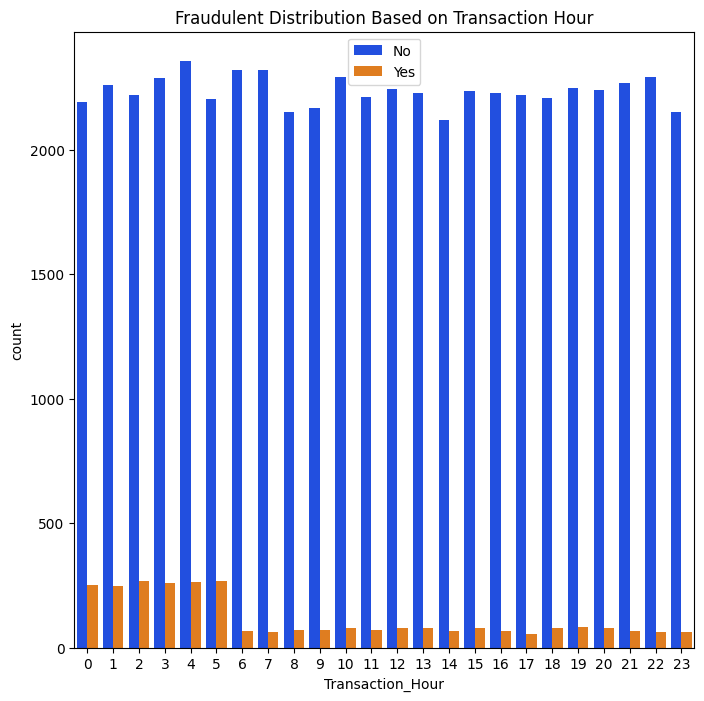

In [31]:
plt.figure(figsize=(8,8))
sns.countplot(x="Transaction_Hour", data=df, palette='bright',hue='Fraudulent')
plt.legend(['No','Yes'])
plt.title('Fraudulent Distribution Based on Transaction Hour')

```markdown

Dari visualisasi diatas terdapat beberapa informasi, namun data fraud masih sangat jauh berbeda dibandingkan data yang tidak fraud. Tetapi masih dapat mengidentifikasi profil pelanggan yang berbeda-beda yang lebih cenderung terlibat dalam transaksi penipuan.

* Dapat dilihat pada grafik bahwa transaksi dengan rata-rata di atas 220$ lebih cenderung diidentifikasi sebagai transaksi penipuan.
* Namun dapat dilihat juga jika rata-rata dari Account_Age dibawah 125 hari akan dianggap sebagai Frauduluent
* Dan yang terakhir bisa dilihat bahwa Fraudulent terjadi saat di jam 0 - 5


```

### **Handle Categorical Data** ###

In [32]:
# memilih data kategorikal dari dataset
categorical = df.select_dtypes(include=['object']).columns.tolist()
categorical

['Payment_Method', 'Product_Category', 'Device_Used']

In [33]:
df['Payment_Method'].value_counts()

Payment_Method
debit card       14334
credit card      14114
bank transfer    14035
PayPal           13995
Name: count, dtype: int64

In [34]:
df['Payment_Method'] = df['Payment_Method'].map({"debit card":0,"credit card":1,"PayPal":2,"bank transfer":3})

In [35]:
df['Product_Category'].value_counts()

Product_Category
health & beauty    11454
home & garden      11412
toys & games       11296
clothing           11251
electronics        11065
Name: count, dtype: int64

In [36]:
df['Product_Category'] = df['Product_Category'].map({"home & garden":0,"electronics":1,"toys & games":2,"clothing":3,"health & beauty":4})

In [37]:
df['Device_Used'].value_counts()

Device_Used
tablet     18992
mobile     18907
desktop    18579
Name: count, dtype: int64

In [38]:
#categorical encoding dengan frequency encoding
df_encoded = df.copy()
cat_cols = ['Payment_Method', 'Product_Category', 'Device_Used']
for col in cat_cols:

    freq = df_encoded[col].value_counts(normalize=True)

    df_encoded[col] = df_encoded[col].map(freq)

df_encoded.drop (cat_cols, axis = 1, inplace=True)

df_encoded.head()

,Transaction_Amount,Quantity,Customer_Age,Fraudulent,Account_Age_Days,Transaction_Hour,Address_Match
0,58.09,1,17.0,0,30,5,1
1,389.96,2,40.0,0,72,8,1
2,134.19,2,22.0,0,63,3,1
3,226.17,5,31.0,0,124,20,1
4,121.53,2,51.0,0,158,5,1


In [39]:
df['Device_Used'] = df['Device_Used'].map({"desktop":0,"mobile":1,"tablet":2,})

In [40]:
df.head()

,Transaction_Amount,Payment_Method,Product_Category,Quantity,Customer_Age,Device_Used,Fraudulent,Account_Age_Days,Transaction_Hour,Address_Match
0,58.09,3,1,1,17.0,2,0,30,5,1
1,389.96,0,1,2,40.0,0,0,72,8,1
2,134.19,2,0,2,22.0,2,0,63,3,1
3,226.17,3,3,5,31.0,0,0,124,20,1
4,121.53,3,3,2,51.0,2,0,158,5,1


In [41]:
new_column_order = ['Transaction_Amount', 'Payment_Method', 'Product_Category', 'Quantity',
                   'Customer_Age', 'Device_Used','Address_Match' , 'Account_Age_Days',
                   'Transaction_Hour','Fraudulent']
df = df.reindex(columns=new_column_order)
df

,Transaction_Amount,Payment_Method,Product_Category,Quantity,Customer_Age,Device_Used,Address_Match,Account_Age_Days,Transaction_Hour,Fraudulent
0,58.09,3,1,1,17.0,2,1,30,5,0
1,389.96,0,1,2,40.0,0,1,72,8,0
2,134.19,2,0,2,22.0,2,1,63,3,0
3,226.17,3,3,5,31.0,0,1,124,20,0
4,121.53,3,3,2,51.0,2,1,158,5,0
...,...,...,...,...,...,...,...,...,...,...
56473,12.25,1,0,4,36.0,0,1,339,21,0
56474,200.81,0,0,2,26.0,0,1,40,7,0
56475,232.83,2,2,2,28.0,2,1,304,9,0
56476,64.25,0,2,2,48.0,2,1,161,2,0


In [42]:
# Standart Scaling -
numeric_features = ['Transaction_Amount', 'Quantity', 'Customer_Age', 'Account_Age_Days', 'Transaction_Hour']
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
df.head()

,Transaction_Amount,Payment_Method,Product_Category,Quantity,Customer_Age,Device_Used,Address_Match,Account_Age_Days,Transaction_Hour,Fraudulent
0,-0.638275,3,1,-1.410309,-1.815956,2,1,-1.401341,-0.901959,0
1,0.620840,0,1,-0.702712,0.544215,0,1,-1.007596,-0.471659,0
2,-0.349551,2,0,-0.702712,-1.302875,2,1,-1.091970,-1.188826,0
3,-0.000579,3,3,1.420082,-0.379330,0,1,-0.520101,1.249544,0
4,-0.397583,3,3,-0.702712,1.672993,2,1,-0.201354,-0.901959,0


## **Heatmap** ##

<Axes: >

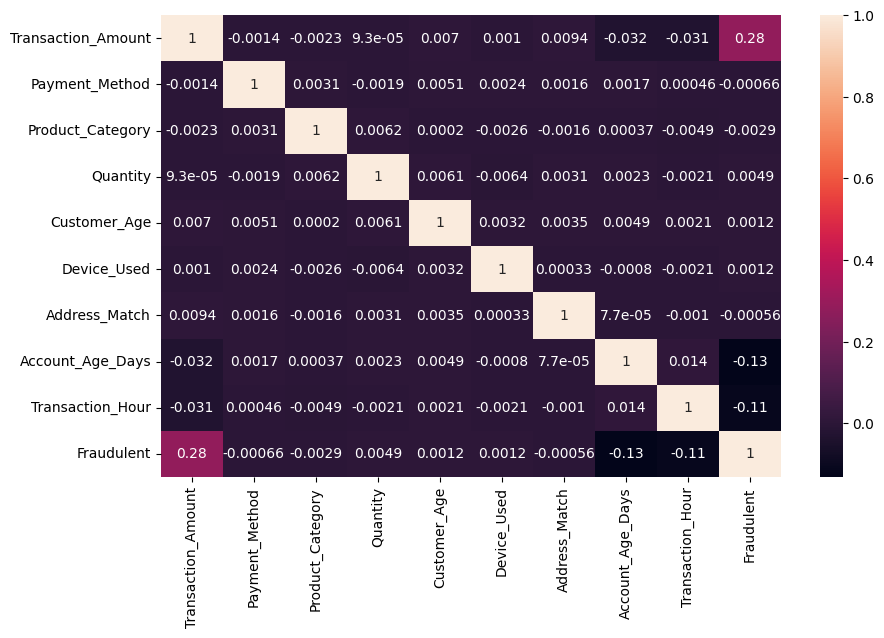

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

```markdown

Dari heatmap diatas menunjukkan bahwa Transaction_Amount memiliki karakteristik yang cukup penting untuk mempengaruhi kemungkinan suatu transaksi bersifat penipuan atau tidak, tetapi korelasi antara fitur diatas tidak menunjukkan informasi yang signifikan
```

## **Feature Selection** ##

In [44]:
rf_model = RandomForestClassifier(random_state=42)

In [45]:
X = df.drop('Fraudulent', axis=1)
y = df['Fraudulent']

In [46]:
rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [47]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns

In [48]:
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

In [49]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [50]:
print(feature_importance_df)

              Feature  Importance
0  Transaction_Amount    0.325951
7    Account_Age_Days    0.234580
4        Customer_Age    0.128329
8    Transaction_Hour    0.111647
2    Product_Category    0.053314
3            Quantity    0.051952
1      Payment_Method    0.045435
5         Device_Used    0.036062
6       Address_Match    0.012730


In [51]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier


X = df_encoded.drop(columns=['Fraudulent'])
y = df_encoded['Fraudulent']
clf = RandomForestClassifier()

# Inisialisasi RFE dengan classifier dan jumlah fitur yang akan dipilih
rfe = RFE(estimator=clf, n_features_to_select=10)

# Fit data
rfe.fit(X, y)

selected_features = pd.DataFrame({'Feature': X.columns, 'Selected': rfe.support_})
print(selected_features[selected_features['Selected']])

c:\Users\Joe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=6. There will be no feature selection and all features will be kept.
  warnings.warn(


              Feature  Selected
0  Transaction_Amount      True
1            Quantity      True
2        Customer_Age      True
3    Account_Age_Days      True
4    Transaction_Hour      True
5       Address_Match      True


### **Modeling** ###

In [52]:
X = df.drop('Fraudulent', axis=1)
y = df['Fraudulent']
X.shape, y.shape

((56478, 9), (56478,))

In [53]:
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)
print(X_resampled.shape,y_resampled.shape)

(107302, 9) (107302,)


In [54]:
rus = RandomUnderSampler(sampling_strategy='majority')
X_under_resampled, y_under_resampled = rus.fit_resample(X, y)
print(X_under_resampled.shape,y_under_resampled.shape)

(5654, 9) (5654,)


In [55]:
print(y_resampled.value_counts())
print(y_under_resampled.value_counts())

Fraudulent
0    53651
1    53651
Name: count, dtype: int64
Fraudulent
0    2827
1    2827
Name: count, dtype: int64


### **Random Forest Classifier** ###

In [56]:
# Random under sampling
X_train,X_test,y_train,y_test = train_test_split(X_under_resampled,y_under_resampled,test_size=0.2,random_state=42)
model = RandomForestClassifier(random_state=42)

In [57]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred = model.predict(X_test)

In [59]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76       581
           1       0.76      0.70      0.73       550

    accuracy                           0.75      1131
   macro avg       0.75      0.74      0.74      1131
weighted avg       0.75      0.75      0.74      1131



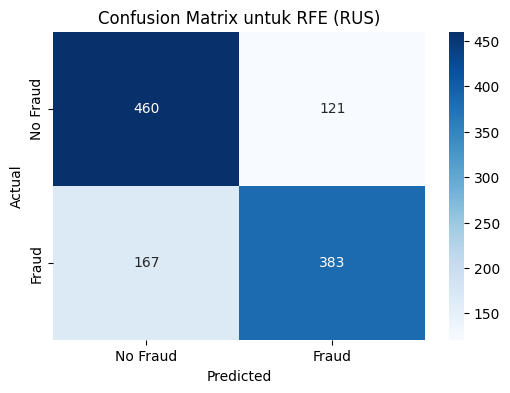

In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix untuk RFE (RUS)')
plt.show()

In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), 
                           X_under_resampled, y_under_resampled, cv=5)

In [63]:
train_score = model.score(X_train, y_train)

In [64]:
print(f"Training Score: {train_score:.4f}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Training Score: 1.0000
Mean CV Score: 0.7405 (+/- 0.0430)


In [65]:
# SMOTE
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)
model = RandomForestClassifier(random_state=42)

In [66]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [67]:
y_pred = model.predict(X_test)

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10786
           1       0.96      0.96      0.96     10675

    accuracy                           0.96     21461
   macro avg       0.96      0.96      0.96     21461
weighted avg       0.96      0.96      0.96     21461



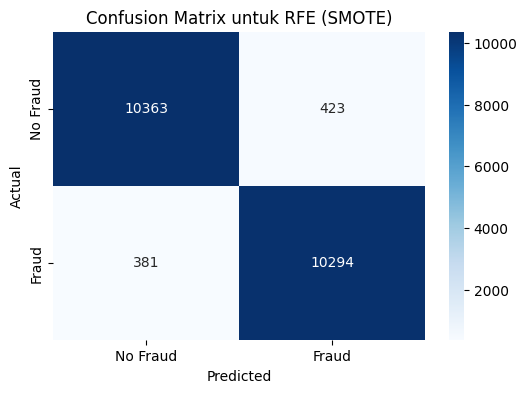

In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix untuk RFE (SMOTE)')
plt.show()

In [70]:
# Train and validation scores from cross validation
from sklearn.model_selection import cross_val_score

In [71]:
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), 
                           X_resampled, y_resampled, cv=5)

In [72]:
train_score = model.score(X_train, y_train)

In [73]:
print(f"Training Score: {train_score:.4f}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Training Score: 1.0000
Mean CV Score: 0.9644 (+/- 0.0295)


### **Local Outlier Factor** ###

In [74]:
# Menggunakan Local Outlier Factor (LOF) untuk menangani class imbalance
fraud_df = df[df['Fraudulent'] == 1]
nofraud_df = df[df['Fraudulent'] == 0].sample(n=len(fraud_df), random_state=42)

df_balanced = pd.concat([fraud_df, nofraud_df])

In [75]:
X_balanced = df_balanced.drop('Fraudulent', axis=1)
y_balanced = df_balanced['Fraudulent']

In [76]:
numeric_features = ['Transaction_Amount', 'Account_Age_Days', 'Transaction_Hour']
scaler = StandardScaler()
X_balanced[numeric_features] = scaler.fit_transform(X_balanced[numeric_features])

In [77]:
y_balanced.value_counts()

Fraudulent
1    2827
0    2827
Name: count, dtype: int64

In [78]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.3, novelty=True)
fitur_numerik = ['Transaction_Amount', 'Account_Age_Days', 'Transaction_Hour']

In [79]:
X_balanced_numerik = df_balanced[fitur_numerik]
X_balanced_scaled = scaler.fit_transform(X_balanced_numerik)

In [80]:
lof.fit(X_balanced_scaled)

LocalOutlierFactor(contamination=0.3, novelty=True)

In [81]:
y_pred_lof = lof.predict(X_balanced_scaled)
y_pred_lof = [1 if pred == -1 else 0 for pred in y_pred_lof]

In [82]:
print(classification_report(y_balanced, y_pred_lof))

              precision    recall  f1-score   support

           0       0.52      0.76      0.62      2827
           1       0.56      0.30      0.39      2827

    accuracy                           0.53      5654
   macro avg       0.54      0.53      0.50      5654
weighted avg       0.54      0.53      0.50      5654



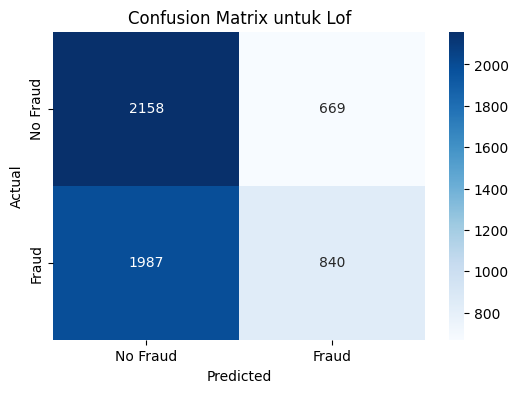

In [83]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_balanced, y_pred_lof)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix untuk Lof')
plt.show()

### **SVM Model** ###

In [84]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

In [86]:
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train, y_train)

SVC(random_state=42)

In [87]:
y_pred_svc = svc_model.predict(X_test)

In [88]:
print("Accuracy SVM:", accuracy_score(y_test, y_pred_svc))


Accuracy SVM: 0.7126436781609196


In [89]:
print (classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.68      0.79      0.73       550
           1       0.76      0.64      0.70       581

    accuracy                           0.71      1131
   macro avg       0.72      0.71      0.71      1131
weighted avg       0.72      0.71      0.71      1131



In [90]:
cv_scores = cross_val_score(SVC(random_state=42), 
                           X_balanced, y_balanced, cv=5)

In [91]:
train_score = model.score(X_balanced, y_balanced)

In [92]:
print(f"Training Score: {train_score:.4f}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Training Score: 0.6525
Mean CV Score: 0.7252 (+/- 0.0259)


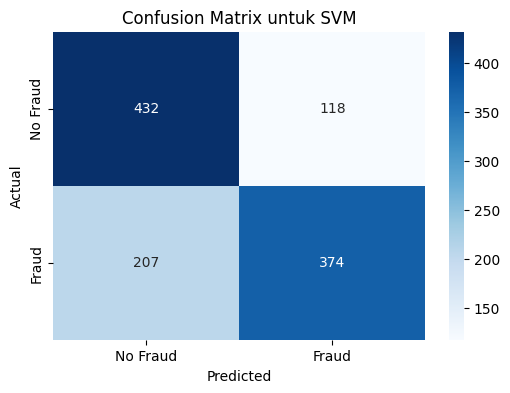

In [93]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix untuk SVM')
plt.show()

In [94]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.3, random_state=42)

In [95]:
iso_forest.fit(X_balanced_scaled)

IsolationForest(contamination=0.3, random_state=42)

In [96]:
y_pred_iso = iso_forest.predict(X_balanced_scaled)
y_pred_iso = [1 if pred == -1 else 0 for pred in y_pred_iso]

In [97]:
print(classification_report(y_balanced, y_pred_iso))

              precision    recall  f1-score   support

           0       0.54      0.76      0.63      2827
           1       0.59      0.36      0.45      2827

    accuracy                           0.56      5654
   macro avg       0.57      0.56      0.54      5654
weighted avg       0.57      0.56      0.54      5654



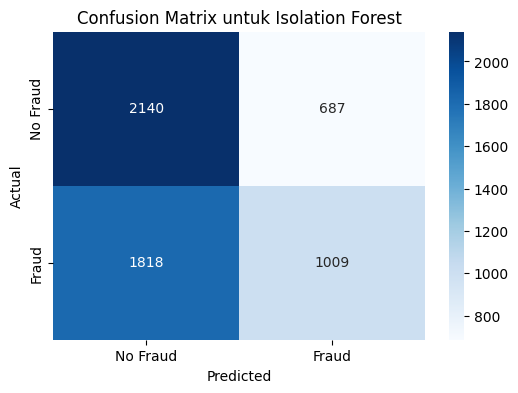

In [98]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_balanced, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix untuk Isolation Forest')
plt.show()

In [107]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Latih ulang RandomForest pada data hasil SMOTE (X_resampled, y_resampled sudah tersedia di notebook)
rf_smote = RandomForestClassifier (random_state=42)
rf_smote.fit(X_under_resampled, y_under_resampled)

# Simpan model ke file .model
joblib.dump(rf_smote, 'Credit.pickle')

print("Model RandomForest (SMOTE) disimpan sebagai 'Credit.pickle'")

Model RandomForest (SMOTE) disimpan sebagai 'Credit.pickle'


Dari hasil diatas bisa disimpulkan bahwa data yang kita proses adalah hasil klasifikasi. Lalu kita perlu melihat seberapa
baik model itu bekerja, dan dalam kasus ini dipakai 6 model dengan masing-masing berbeda hasilnya. Dan perlu dicatat hasil
dari confussion matrix ataupun cross validation sangat berpengaruh terhadap pemilihan model. Namun dalam kasus ini jika
ingin melihat hanya dari confussion matrix maka hasil dari Precission dan Recall sangat penting. 

---

### **Random Forest Classifier (RUS)** ###
| Kelas | Precision | Recall |
|-------|----------|-----|
| 0 | 0.71 | 0.78 | 
| 1 | 0.74 | 0.67 | 

Penjelasan:
**kelas tidak fraud (0)**

- **precision: 0.71**

- **recall: 0.78**
```
Dari hasil ini model belum mampu dalam mendekteksi fraud dengan benar dan ada transaksi yang dapat dianggap sebagai fraud namun lolos, 
namun model dapat mengenali transaksi normal dengan baik.
```
**kelas fraud (1)**

- **precision: 0.74**

- **recall: 0.67**
```
Dari hasil ini model belum mampu mendeteksi transaksi yang fraud dikarenakan recall rendah, 
namun model dapat mendeteksi dengan baik transaksi fraud.
```
---

### **Random Forest Classifier (SMOTE)** ###
| Kelas | Precision | Recall |
|-------|----------|-----|
| 0 | 0.96 | 0.96 | 
| 1 | 0.96 | 0.96 | 


Penjelasan:
**kelas tidak fraud (0)**

- **precision: 0.97**

- **recall: 0.96**
```
Dari model ini sudah dapat mendeteksi transaksi yang normal dengan sangat baik dan model 
juga dapat mendeteksi transaksi normal yang dianggap sebagai fraud.
```
**kelas fraud (1)**

- **precision: 0.96**

- **recall: 0.97**
```
Dari model ini sudah dapat mendeteksi transaksi yang tidak normal atau fraud dengan sangat baik. 
```
---

### **Local Outlier Factor (LOF)** ###
| Kelas | Precision | Recall |
|-------|-----------|--------|
| 0 | 0.52 | 0.76 | 
| 1 | 0.56 | 0.30 |

Penjelasan:
**kelas tidak fraud (0)**  
- **precision: 0.52**
- **recall: 0.76**  
```
Dari metrik di atas model tidak dapat mendeteksi transaksi yang normal dikarenakan precision yang sangat rendah, 
namun dari data transaksi yang ada cukup bisa mengenali mana yang transaksi normal
```
**kelas fraud (1)**  
- **precision: 0.30**  
- **recall: 0.56** 
```
Dari metrik di atas model tidak mampu dalam mendeteksi transaksi fraud dengan benar karena skornya sangat rendah, 
lalu model juga tidak dapat mendeteksi data yang benar-benar fraud
```
---

### **Isolation Forest (IF)** ###
| Kelas | Precision | Recall |
|-------|-----------|--------|
| 0 | 0.54 | 0.76 |
| 1 | 0.59 | 0.36 |

Penjelasan:
**kelas tidak fraud (0)**  
- **precision: 0.54** 
- **recall: 0.76** 
```
Dari hasil diatas model juga belum mampu medeteksi transaksi yang normal dengan maksimal,
namun model tidak dapat memprediksi data yang benar-benar normal
```
**kelas fraud (1)**  
- **precision: 0.59**  
- **recall: 0.36** 
``` 
Dari hasil model diatas belum mampu mendeteksi transaksi yang benar benar fraud,
lalu model juga belum bisa memprediksi transaksi yag benar-benar fraud
```
---

### **Support Vector Machine (SVM)** ###
| Kelas | Precision | Recall |
|-------|-----------|--------|
| 0 | 0.68 | 0.79 |
| 1 | 0.76 | 0.64 |

Penjelasan:
**kelas tidak fraud (0)**  
- **precision: 0.68**  
- **recall: 0.79**  
```
Model tidak dapat memprediksi transaksi yang normal dengan benar, 
namun dari semua transaksi yang normal model dapat mendeteksi dengan benar 
```
**kelas fraud (1)**  
- **precision: 0.76**  
- **recall: 0.64**  
```
model dapat memprediksi hasil yang fraud dengan cukup benar,
lalu dari data yang fraud model belum bisa menangkap transaksi yang tidak normal
```


--- 


### **Kesimpulan** ###

Dari hasil model yang sudah diinterpretasikan diatas. Kami memilih metode Random Forest Classifier (SMOTE) sebagai model untuk mendeteksi fraud 
dikarenakan model ini mempunyai keseimbangan dalam hasil metriknya dan bedanya tidak terlalu jauh dan memiliki tingkat toleransi yang cukup untuk metrik
yang sangat tinggi.

Metode **Data Preprocessing**, **Feature Engineering**, **Correlation Matrix** maupun **Modeling** sangat berpengaruh terhadap hasil yang diharapkan. Dan
proses ini dianggap penting atas keberlangsungan hasil yang diinginkan.

Namun, disamping itu semua dari hasil pengujian serta alur kerja diatas dapat disimpulkan bahwa di era digitalisasi seperti sekarang
banyak kasus fraudulent yang bisa merugikan banyak perusahaan dan didalam kasus ini model yang kami buat diharapkan bisa mengurangi kasus penipuan 

***Catatan: Hasil model yang dipilih dapat dilakukan sampling ulang bila metriknya dianggap terlalu tinggi. Metode ini dapat membuat model semakin 
robust dan dapat diimplementasikan ke dunia perbankan***
